### Importación de datos



In [48]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [49]:
# Guardamos todas las tiendas en un diccionario
tiendas = {
    "Tienda 1": tienda,
    "Tienda 2": tienda2,
    "Tienda 3": tienda3,
    "Tienda 4": tienda4
}

facturacion_total = 0
facturaciones = {}

# Análisis por tienda
for nombre, df in tiendas.items():

    precios = df['Precio'].astype(float)

    facturacion = precios.sum()
    promedio = precios.mean()
    ventas = precios.count()

    facturacion_total += facturacion
    facturaciones[nombre] = facturacion

    print(f"\n--- {nombre} ---")
    print(f"Facturación: ${facturacion:.2f}")
    print(f"Número de ventas: {ventas}")
    print(f"Promedio por venta: ${promedio:.2f}")

# Facturación total
print(f"\nFacturación total de todas las tiendas: ${facturacion_total:.2f}")

# Tienda con mayor facturación
mejor_tienda = max(facturaciones, key=facturaciones.get)
print(f"La tienda con mayor facturación es: {mejor_tienda}")


--- Tienda 1 ---
Facturación: $1150880400.00
Número de ventas: 2359
Promedio por venta: $487867.91

--- Tienda 2 ---
Facturación: $1116343500.00
Número de ventas: 2359
Promedio por venta: $473227.43

--- Tienda 3 ---
Facturación: $1098019600.00
Número de ventas: 2359
Promedio por venta: $465459.77

--- Tienda 4 ---
Facturación: $1038375700.00
Número de ventas: 2358
Promedio por venta: $440362.89

Facturación total de todas las tiendas: $4403619200.00
La tienda con mayor facturación es: Tienda 1


# 2. Ventas por categoría

In [50]:
# Guardar las tiendas en un diccionario
tiendas = {
    "Tienda 1": tienda,
    "Tienda 2": tienda2,
    "Tienda 3": tienda3,
    "Tienda 4": tienda4
}

# Función para analizar ventas por categoría
def ventas_por_categoria(df, nombre):

    # Convertir precios a número por si vienen como texto
    df['Precio'] = df['Precio'].astype(float)

    # Agrupar por categoría y sumar ventas
    ventas = df.groupby('Categoría del Producto')['Precio'].sum()

    # Ordenar de mayor a menor
    ventas = ventas.sort_values(ascending=False)

    print(f"\n--- Ventas por categoría en {nombre} ---")
    print(ventas)

    # Mostrar la categoría con más ventas
    mejor_categoria = ventas.idxmax()
    print(f"\nCategoría más vendida en {nombre}: {mejor_categoria}")

# Ejecutar análisis para todas las tiendas
for nombre, df in tiendas.items():
    ventas_por_categoria(df, nombre)


--- Ventas por categoría en Tienda 1 ---
Categoría del Producto
Electrónicos               429493500.0
Electrodomésticos          363685200.0
Muebles                    187633700.0
Instrumentos musicales      91299000.0
Deportes y diversión        39290000.0
Juguetes                    17995700.0
Artículos para el hogar     12698400.0
Libros                       8784900.0
Name: Precio, dtype: float64

Categoría más vendida en Tienda 1: Electrónicos

--- Ventas por categoría en Tienda 2 ---
Categoría del Producto
Electrónicos               410831100.0
Electrodomésticos          348567800.0
Muebles                    176426300.0
Instrumentos musicales     104990300.0
Deportes y diversión        34744500.0
Juguetes                    15945400.0
Artículos para el hogar     14746900.0
Libros                      10091200.0
Name: Precio, dtype: float64

Categoría más vendida en Tienda 2: Electrónicos

--- Ventas por categoría en Tienda 3 ---
Categoría del Producto
Electrónicos             

# 3. Calificación promedio de la tienda


In [51]:
# Diccionario con todas las tiendas
tiendas = {
    "Tienda 1": tienda,
    "Tienda 2": tienda2,
    "Tienda 3": tienda3,
    "Tienda 4": tienda4
}

# Función para calcular la clasificación promedio
def clasificacion_promedio(df, nombre):

    promedio = df['Calificación'].astype(float).mean()

    print(f"{nombre} - Clasificación promedio: {promedio:.2f}")

# Ejecutar para todas las tiendas
for nombre, df in tiendas.items():
    clasificacion_promedio(df, nombre)

Tienda 1 - Clasificación promedio: 3.98
Tienda 2 - Clasificación promedio: 4.04
Tienda 3 - Clasificación promedio: 4.05
Tienda 4 - Clasificación promedio: 4.00


# 4. Productos más y menos vendidos

In [52]:
import pandas as pd

# Cargar datos
urls = [
"https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv",
"https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv",
"https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv",
"https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"
]

df_total = pd.concat(
    [pd.read_csv(url).assign(Tienda=f"Tienda {i+1}") for i, url in enumerate(urls)],
    ignore_index=True
)

# Contar ventas por producto
ventas = (
    df_total
    .groupby(['Tienda','Producto'])
    .size()
    .reset_index(name='Cantidad_Vendida')
)

# Función de análisis
def analizar_tienda(df, nombre):

    ordenado = df.sort_values('Cantidad_Vendida', ascending=False)

    print(f"\n{nombre} - TOP 3 productos MÁS vendidos:")
    print(ordenado.head(3)[['Producto','Cantidad_Vendida']])

    print(f"\n{nombre} - TOP 3 productos MENOS vendidos:")
    print(ordenado.tail(3)[['Producto','Cantidad_Vendida']])

# Analizar cada tienda
for tienda_nombre, datos in ventas.groupby('Tienda'):
    analizar_tienda(datos, tienda_nombre)


Tienda 1 - TOP 3 productos MÁS vendidos:
         Producto  Cantidad_Vendida
1         Armario                60
48  TV LED UHD 4K                60
33     Microondas                60

Tienda 1 - TOP 3 productos MENOS vendidos:
                     Producto  Cantidad_Vendida
37            Olla de presión                35
13               Celular ABXY                33
4   Auriculares con micrófono                33

Tienda 2 - TOP 3 productos MÁS vendidos:
                     Producto  Cantidad_Vendida
75  Iniciando en programación                65
84                 Microondas                62
58                    Batería                61

Tienda 2 - TOP 3 productos MENOS vendidos:
           Producto  Cantidad_Vendida
74        Impresora                34
82  Mesa de comedor                34
77    Juego de mesa                32

Tienda 3 - TOP 3 productos MÁS vendidos:
            Producto  Cantidad_Vendida
129    Kit de bancas                57
133  Mesa de comedor        

# 5. Envío promedio por tienda

In [53]:
# Asegurar que el costo de envío sea numérico
df_total['Costo de envío'] = df_total['Costo de envío'].astype(float)

# Calcular el costo de envío promedio por tienda
envio_promedio = (
    df_total
    .groupby('Tienda')['Costo de envío']
    .mean()
    .round(2)
)

# Mostrar resultados
print("Costo de envío promedio por tienda:\n")
print(envio_promedio)

Costo de envío promedio por tienda:

Tienda
Tienda 1    26018.61
Tienda 2    25216.24
Tienda 3    24805.68
Tienda 4    23459.46
Name: Costo de envío, dtype: float64


# 6. Graficos


Facturación por tienda

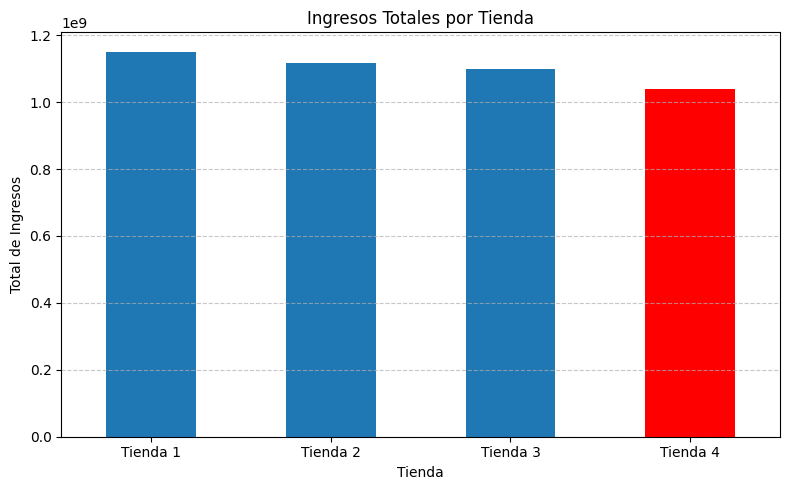

In [54]:
import matplotlib.pyplot as plt

# Agrupar ingresos por tienda
ingresos_totales = df_total.groupby('Tienda')['Precio'].sum().sort_values(ascending=False)

# Detectar la tienda con menor ingreso
tienda_menor = ingresos_totales.idxmin()

# Crear colores (rojo para la tienda con menor ingreso)
colores = ['red' if tienda == tienda_menor else '#1f77b4' for tienda in ingresos_totales.index]

# Crear gráfico
plt.figure(figsize=(8,5))
ingresos_totales.plot(kind='bar', color=colores)

plt.title('Ingresos Totales por Tienda')
plt.ylabel('Total de Ingresos')
plt.xlabel('Tienda')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("ingresos_tienda.png")
plt.show()

Ventas por categoría

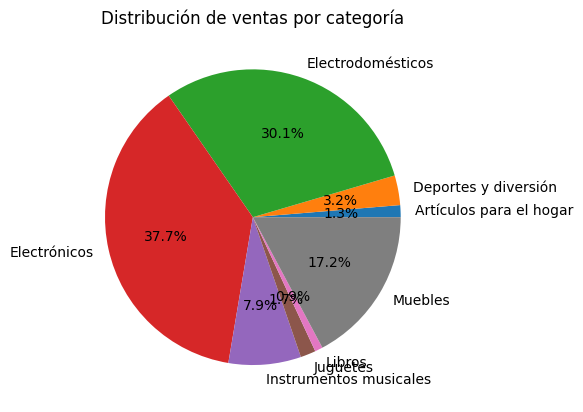

In [55]:
categorias = df_total.groupby('Categoría del Producto')['Precio'].sum()

plt.figure()
categorias.plot(kind='pie', autopct='%1.1f%%')

plt.title("Distribución de ventas por categoría")
plt.ylabel("")

plt.savefig("ventas_categoria.png")
plt.show()

Calificación promedio

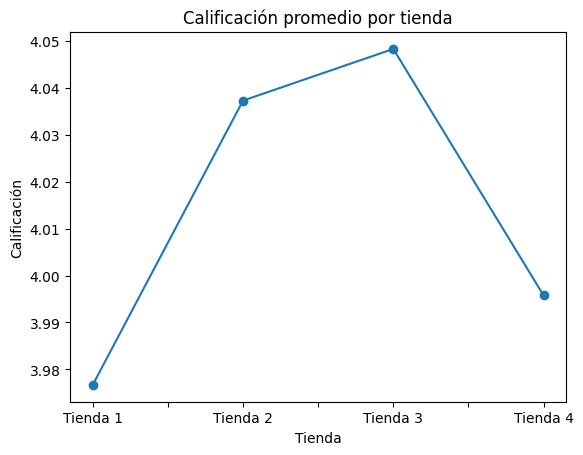

In [56]:
calificacion = df_total.groupby('Tienda')['Calificación'].mean()

plt.figure()
calificacion.plot(kind='line', marker='o')

plt.title("Calificación promedio por tienda")
plt.xlabel("Tienda")
plt.ylabel("Calificación")

plt.savefig("calificacion_promedio.png")
plt.show()

Productos más vendidos

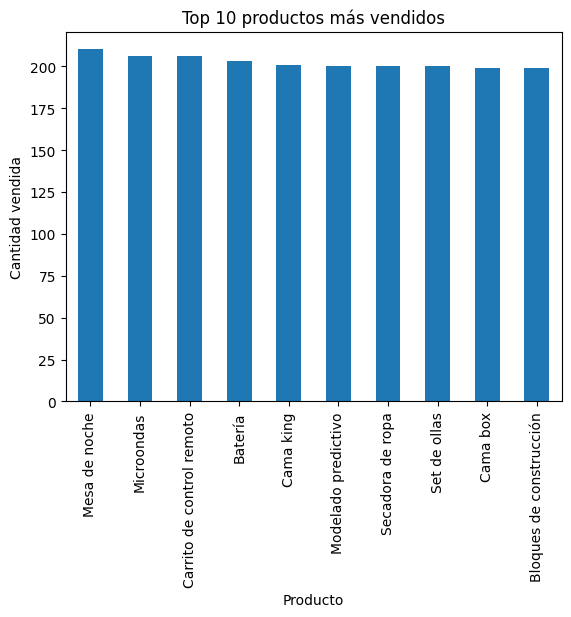

In [57]:
productos = (
    df_total.groupby('Producto')
    .size()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure()
productos.plot(kind='bar')

plt.title("Top 10 productos más vendidos")
plt.xlabel("Producto")
plt.ylabel("Cantidad vendida")

plt.savefig("productos_vendidos.png")
plt.show()

Precio vs costo de envío

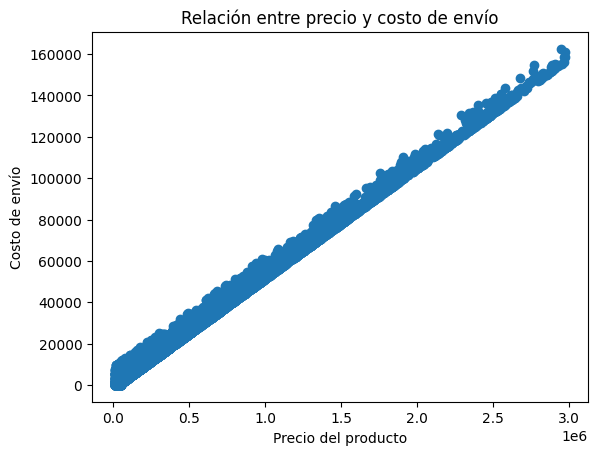

In [58]:
plt.figure()

plt.scatter(df_total['Precio'], df_total['Costo de envío'])

plt.title("Relación entre precio y costo de envío")
plt.xlabel("Precio del producto")
plt.ylabel("Costo de envío")

plt.savefig("precio_envio.png")
plt.show()

# Informe de rendimiento de las tiendas


## Introducción

El objetivo de este análisis fue evaluar el desempeño de cuatro tiendas para determinar en cuál de ellas el Sr. Juan debería vender sus productos. Para tomar esta decisión se analizaron diferentes factores, incluyendo los ingresos totales de cada tienda, las categorías de productos más y menos vendidas, las calificaciones promedio de los clientes, los productos más vendidos y el costo promedio de envío.

Además, se generaron diversas visualizaciones que permiten comprender mejor los patrones y resultados obtenidos en cada tienda.

---

## Ingresos totales por tienda

En primer lugar, se analizaron los ingresos totales generados por cada tienda. Este indicador permite identificar cuál tienda tiene mayor volumen de ventas y mayor actividad comercial.

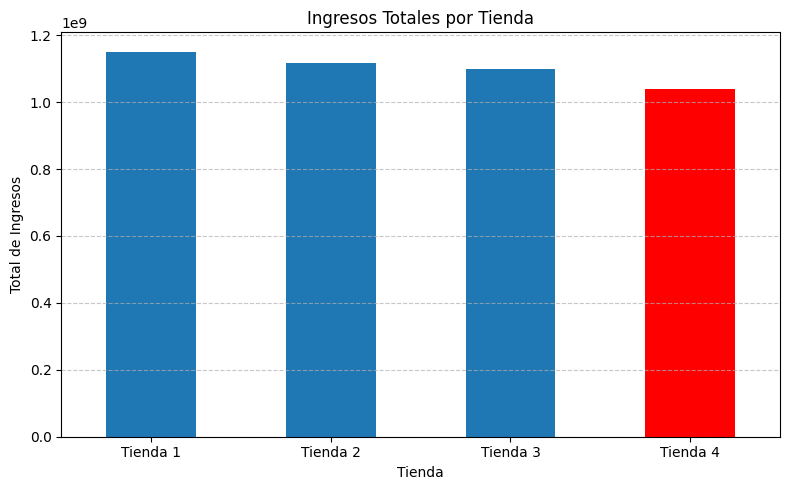

A partir de este análisis se puede observar qué tiendas presentan mejores resultados en términos de ingresos, lo cual es un factor importante para determinar el potencial de ventas.

---

## Ventas por categoría de productos

Posteriormente se analizaron las categorías de productos más vendidas. Esto permite identificar qué tipo de productos tienen mayor demanda entre los clientes.

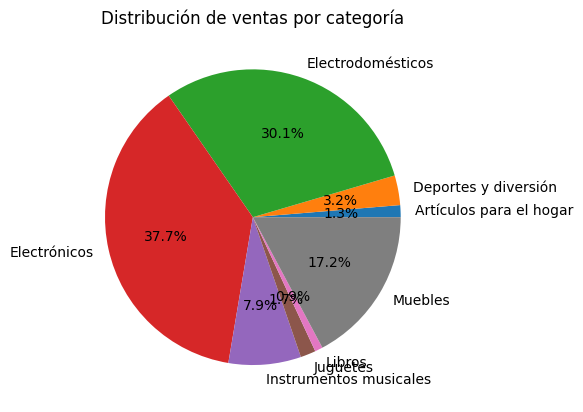

Las categorías con mayor participación representan las principales preferencias de los consumidores dentro de las tiendas.

---

## Calificación promedio de los clientes

También se evaluó la calificación promedio otorgada por los clientes en cada tienda. Este indicador refleja el nivel de satisfacción de los compradores y la calidad del servicio ofrecido.

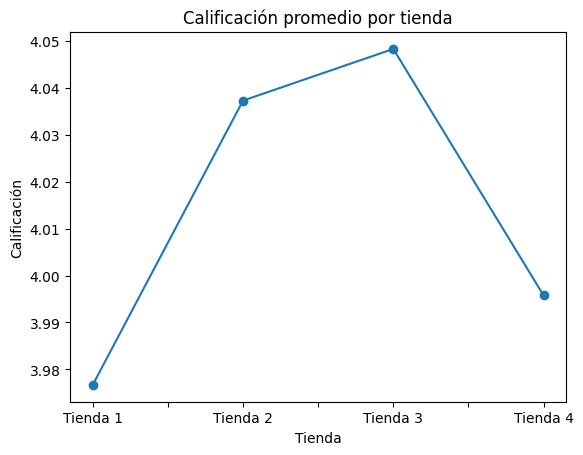

Las tiendas con mejores calificaciones suelen generar mayor confianza entre los clientes y una mejor experiencia de compra.

---

## Productos más vendidos

El análisis de los productos más vendidos permitió identificar cuáles artículos tienen mayor demanda dentro de las tiendas.

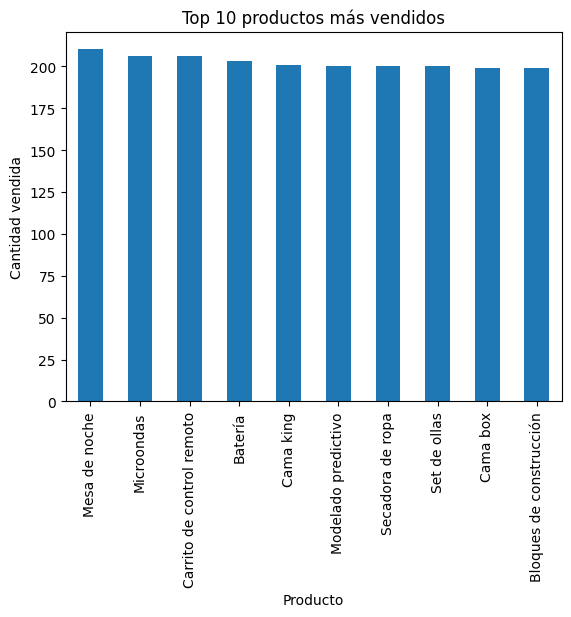

Esta información ayuda a comprender el comportamiento de compra de los clientes y permite identificar oportunidades de negocio.

---

## Relación entre precio y costo de envío

Finalmente, se analizó la relación entre el precio de los productos y el costo de envío. Este factor es relevante ya que el cliente es quien paga el envío, por lo que un costo elevado podría afectar la decisión de compra.

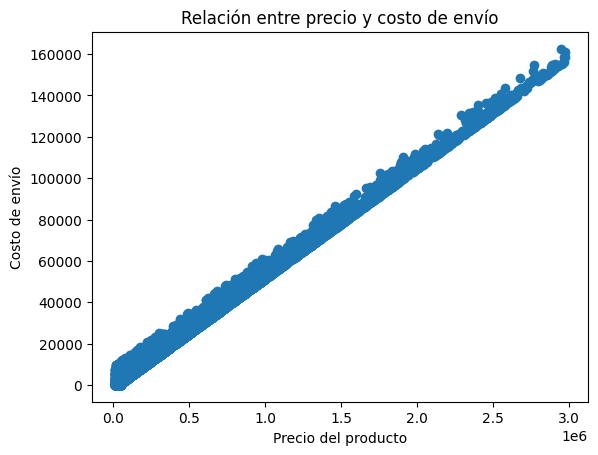)

Las tiendas con costos de envío más competitivos pueden resultar más atractivas para los clientes.

---

## Conclusión

Después de analizar los ingresos totales, las categorías de productos, las calificaciones de los clientes, los productos más vendidos y el costo promedio de envío, se concluye que la tienda con mejor desempeño general es aquella que presenta mayores ingresos, buenas calificaciones de los clientes y costos de envío competitivos.

Por lo tanto, se recomienda que el Sr. Juan venda sus productos en la tienda que obtuvo los mejores resultados en estos análisis, ya que ofrece mayores oportunidades de ventas, una base sólida de clientes y condiciones favorables para el crecimiento del negocio.
